# Experiment with $\eta$
### Test if the agent's trajectory for |RRRRR>|RRRRR>|RRRRR> product state generalizes to mixed state w.r.t $\eta$

In [1]:
import os
import pickle

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")

from src.networks import TransformerPE_2qRDM, PermutationInvariantMLP
from src.mpslib import MPS_to_state, generate_random_MPS, state_to_MPS
from src.ppo import PPOAgent
from src.quantum_env import QuantumEnv
from src.stategen import sample_haar_generalized, sample_haar_product, StateGenerator
from src.config import get_default_config
from src.util import srollout


In [2]:
LOG_PATH = "logs/staged_15q_10000iters_product2/"
CONFIG_PATH = os.path.join(LOG_PATH, "config.yaml")
STATEDICT_PATH = os.path.join(LOG_PATH, "agent-statedict.pickle")

assert os.path.exists(LOG_PATH)
assert os.path.exists(CONFIG_PATH)
assert os.path.exists(STATEDICT_PATH)

In [3]:
config = get_default_config()
config.merge_from_file(CONFIG_PATH)

In [ ]:
# in_shape = int((15*14/2) * 32)
# value_network = PermutationInvariantMLP(in_shape, [128, 256], 1)

# # Initialize policy function
# policy_network = TransformerPE_2qRDM(
#     in_shape,
#     embed_dim=      config.embed_dim,
#     dim_mlp=        config.dim_mlp,
#     n_heads=        config.attn_heads,
#     n_layers=       config.transformer_layers
# )


In [4]:
with open(os.path.join(LOG_PATH, 'agent.pt'), mode='rb') as f:
    agent = torch.load(f, map_location=torch.device('cpu'))

In [5]:
state_generator_1 = StateGenerator(
    sample_haar_product,
    config.num_qubits,
    dict(min_subsystem_size=5,
         max_subsystem_size=5,
    )
)

env1 = QuantumEnv(
        num_qubits=             config.num_qubits,
        num_envs=               1,
        epsi=                   1e-2,
        max_episode_steps=      100,
        reward_fn=              config.reward_fn,
        obs_fn=                 config.obs_fn,
        state_generator=        state_generator_1,
        fast_obs=               False
)
env1.reset()
None

In [6]:
np.random.seed(7)


test_states = []
for _ in range(10):
    env1.reset()
    test_states.append(env1.simulator.states.copy()[0])

In [7]:
test_actions = []
test_probabilities = []

for state in test_states:
    actions, ents, probs = srollout(state, agent, epsi=config.epsi, max_steps=120)
    test_actions.append(actions)
    test_probabilities.append(probs)
    print(len(actions))
    print(np.all(ents[-1] < config.epsi))

71
True
76
True
79
True
73
True
75
True
72
True
73
True
68
True
72
True
62
True


In [27]:
etas = np.linspace(2.0, 6.0, 17, endpoint=True)
etas

array([2.  , 2.25, 2.5 , 2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 ,
       4.75, 5.  , 5.25, 5.5 , 5.75, 6.  ])

In [24]:
state_generator_2 = StateGenerator(
    sample_haar_generalized,
    15,
    dict(
        min_subsystem_size=15,
        max_subsystem_size=15,
        min_eta=10.0,
        max_eta=10.0
    )
)

env2 = QuantumEnv(
        num_qubits=             config.num_qubits,
        num_envs=               1,
        epsi=                   1e-2,
        max_episode_steps=      100,
        reward_fn=              config.reward_fn,
        obs_fn=                 config.obs_fn,
        state_generator=        state_generator_2,
        fast_obs=               False
)
env2.reset()
None

In [57]:
NUM_QUBITS = 15
SUBSYSTEM_SIZES = (5, 5, 5)
BONDS = np.cumsum((0,) + SUBSYSTEM_SIZES)
CHIVEC = np.array([2 ** min(j, NUM_QUBITS - j) for j in range(NUM_QUBITS + 1)])
CHIPAR = CHIVEC[BONDS]


def eta_pertube(psi, eta):
    Gammas, Lambdas = state_to_MPS(psi, CHIVEC, NUM_QUBITS)

    for b, chi in zip(BONDS[1:-1], CHIPAR[1:-1]):
        lambdaM = eta * np.exp(-eta * np.arange(chi))
        lambdaM /= np.linalg.norm(lambdaM)
        Lambdas[b] = lambdaM
        # Recalculate tensors
        psi = MPS_to_state(Gammas, Lambdas, canonical=0)
        Gammas, Lambdas = state_to_MPS(psi, CHIVEC, NUM_QUBITS, 2)

    return MPS_to_state(Gammas, Lambdas, canonical=0).reshape((2,) * NUM_QUBITS)


def test_eta_pertubation(state, actions, eta):
    psi = eta_pertube(state.copy(), eta)
    env = env2
    env2.reset()
    env.set_states(np.expand_dims(psi,0))
    for i, a in enumerate(actions, 1):
        a = env.simulator.actToKey[tuple(a)]
        _, _, term, _, _ = env.step(a, reset=False)
        if term:
            return np.float32(i)
    return np.inf

In [67]:
etas = np.linspace(0.5, 5.5, 21, endpoint=True)
eta_pertubation_results = {}

for state, actions in zip(test_states, test_actions):
    print("\nNew state")
    for eta in etas:
        res = test_eta_pertubation(state, actions, eta)
        eta_pertubation_results.setdefault(eta, []).append(res)
        print(res, end=' ')



New state
inf inf inf inf inf inf inf 69.0 inf 68.0 67.0 66.0 66.0 66.0 66.0 66.0 66.0 66.0 66.0 55.0 55.0 
New state
inf 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 
New state
inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf 
New state
inf inf inf 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 
New state
inf inf inf inf inf inf 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 69.0 
New state
inf inf inf inf inf inf inf inf inf 67.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 
New state
inf inf 68.0 65.0 65.0 65.0 65.0 65.0 65.0 65.0 54.0 54.0 54.0 54.0 54.0 54.0 54.0 54.0 54.0 54.0 54.0 
New state
inf inf inf inf inf 59.0 59.0 59.0 54.0 54.0 54.0 54.0 49.0 49.0 49.0 49.0 49.0 49.0 49.0 49.0 49.0 
New state
inf inf 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 62.0 
New state
in

In [55]:
test_eta_pertubation(test_states[2], test_actions[2], 1)

inf

(0.0, 100.0)

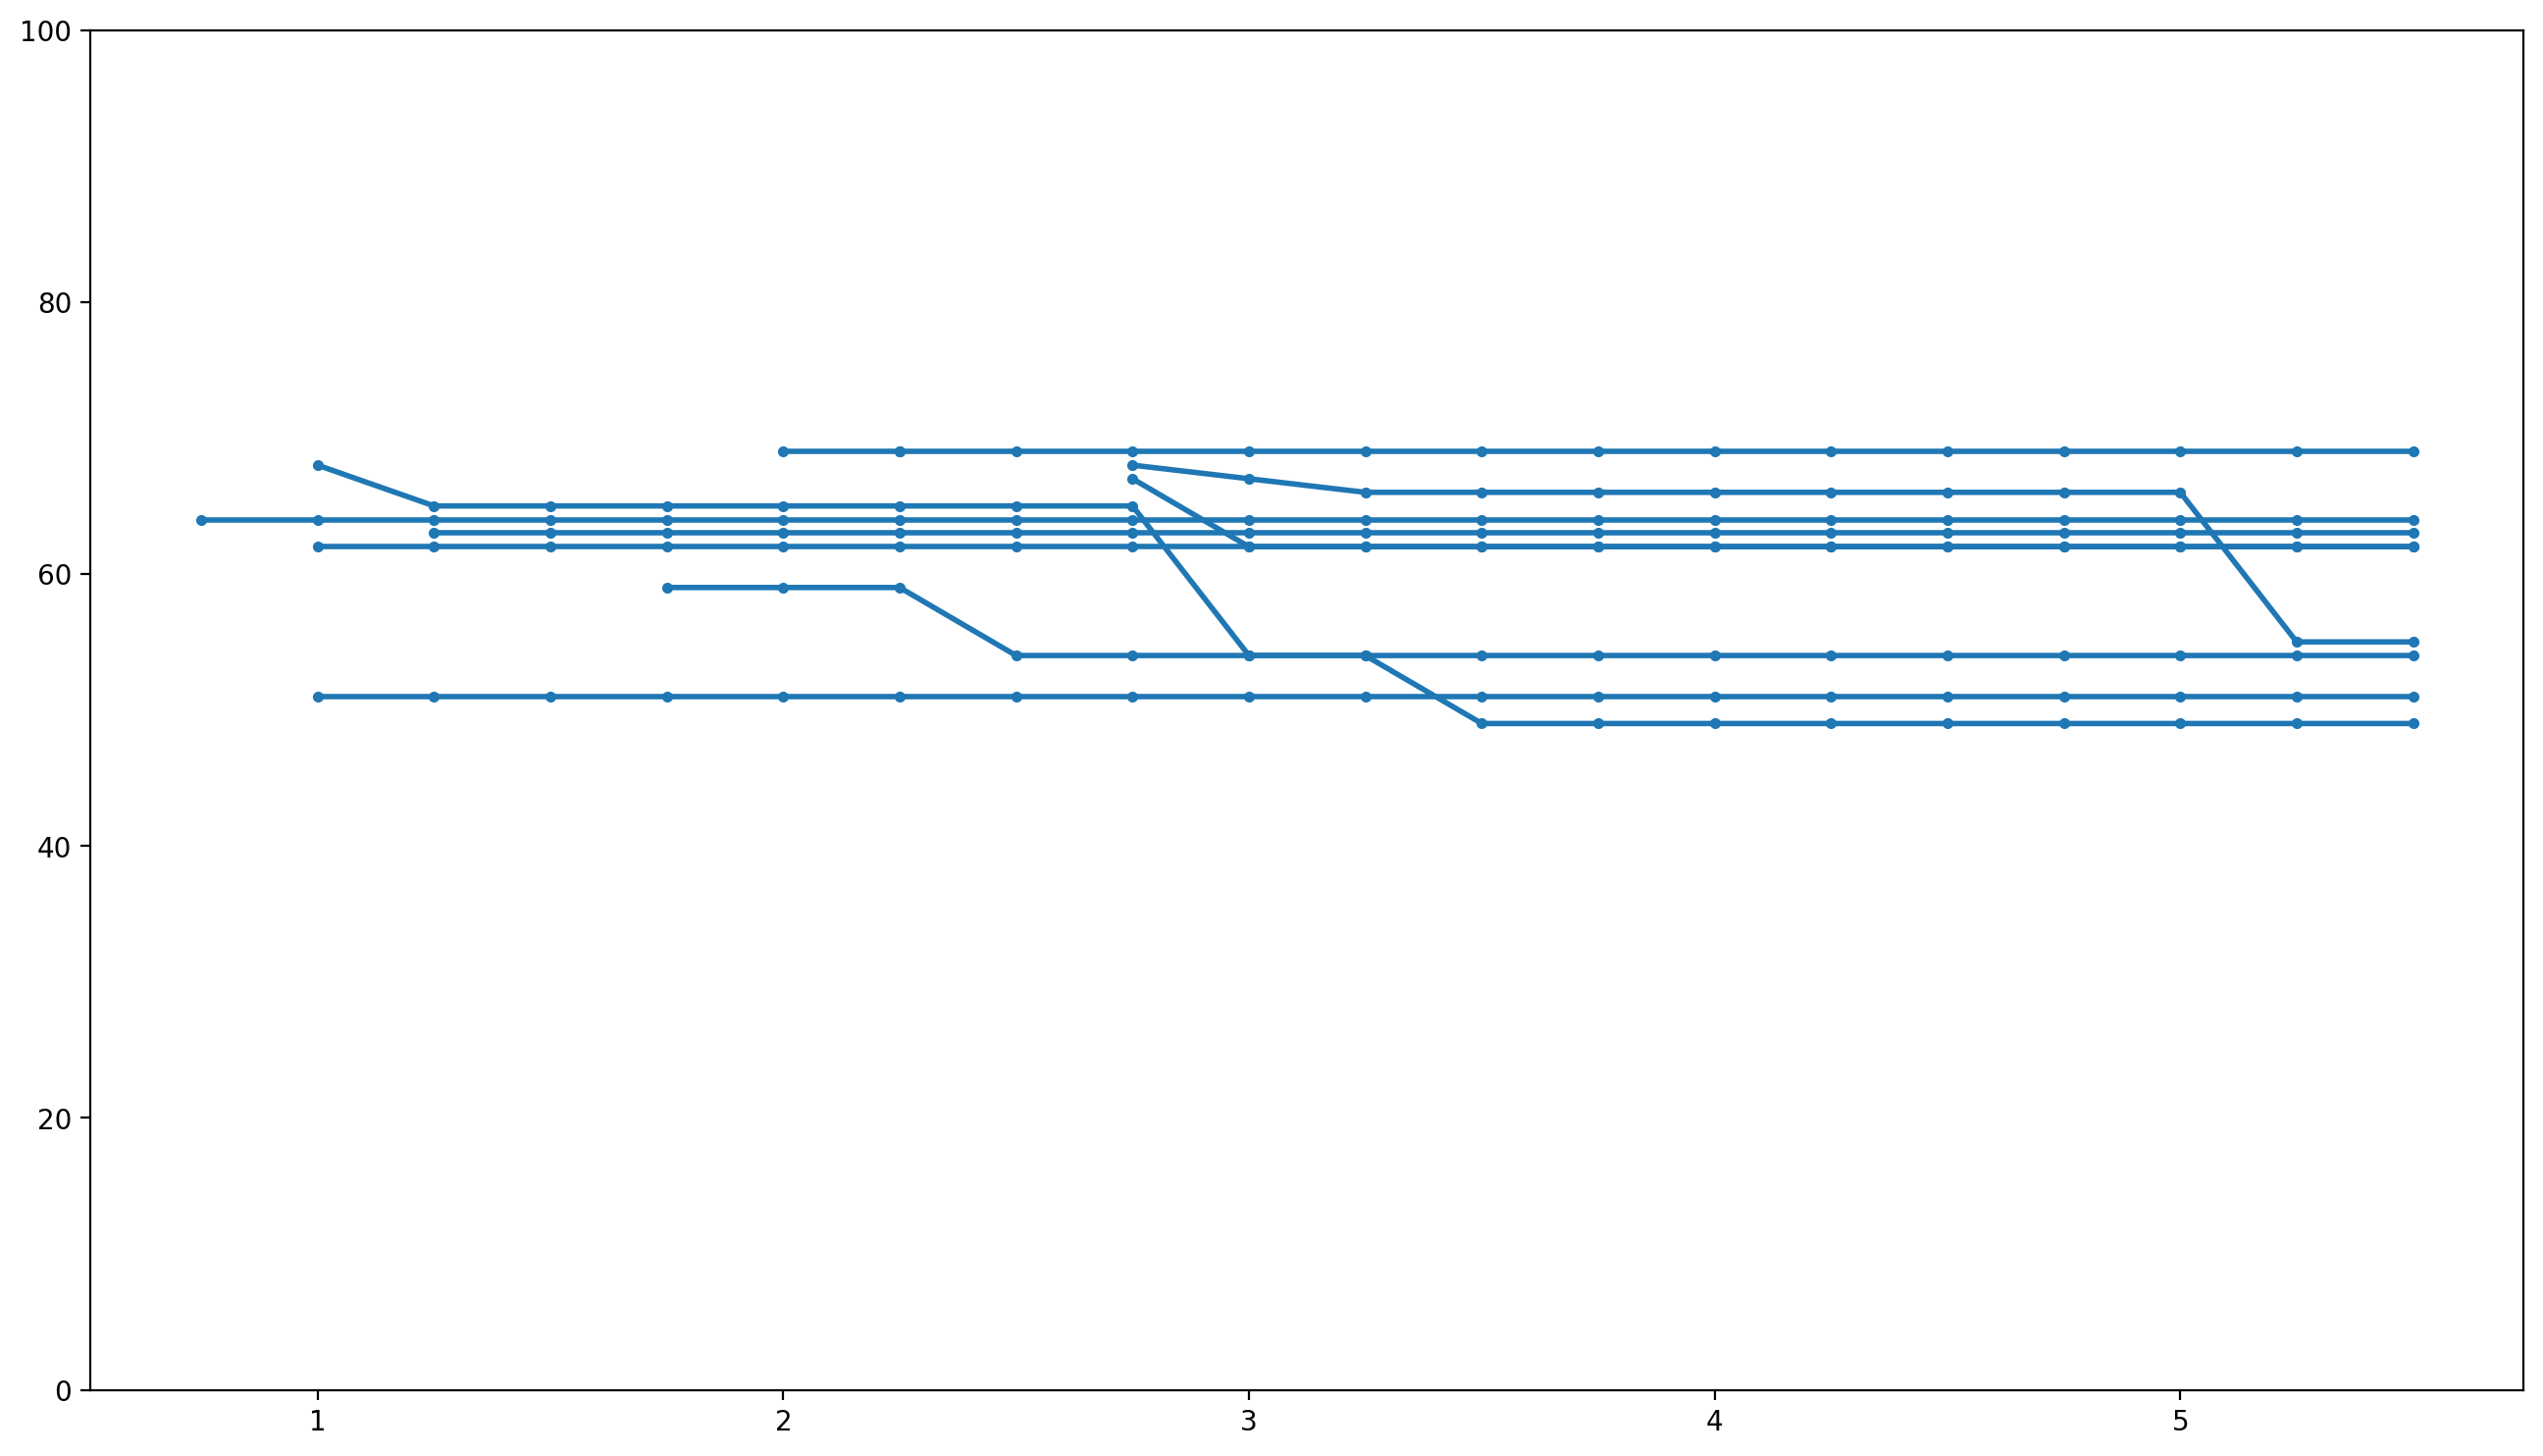

In [71]:
fig, ax = plt.subplots(figsize=(16,9))
for i in range(10):
    xs = list(eta_pertubation_results.keys())
    ys = [eta_pertubation_results[x][i] for x in xs]
    xs, ys = np.array(xs), np.array(ys)
    ys[ys == np.inf] = np.nan
    ax.plot(xs, ys, lw=2, alpha=1.0, marker='.', color='tab:blue')

ax.set_ylim(0, 100)


In [72]:
etas = np.linspace(0.5, 1.5, 31, endpoint=True)
eta_pertubation_results_fine = {}

for state, actions in zip(test_states, test_actions):
    print("\nNew state")
    for eta in etas:
        res = test_eta_pertubation(state, actions, eta)
        eta_pertubation_results.setdefault(eta, []).append(res)
        print(res, end=' ')


New state
inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf 
New state
inf inf 68.0 68.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 64.0 
New state
inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf 
New state
inf inf inf inf inf 63.0 inf 63.0 inf inf 63.0 63.0 63.0 63.0 63.0 inf inf 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 63.0 
New state
inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf 
New state
inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf 
New state
inf inf inf inf inf inf inf inf inf 66.0 66.0 66.0 66.0 65.0 68.0 68.0 68.0 67.0 65.0 65.0 65.0 65.0 65.0 65.0 65.0 65.0 65.0 65.

In [73]:
eta_pertubation_results3 = eta_pertubation_results.copy()
eta_pertubation_results3.update(eta_pertubation_results_fine)

(0.0, 1.05)

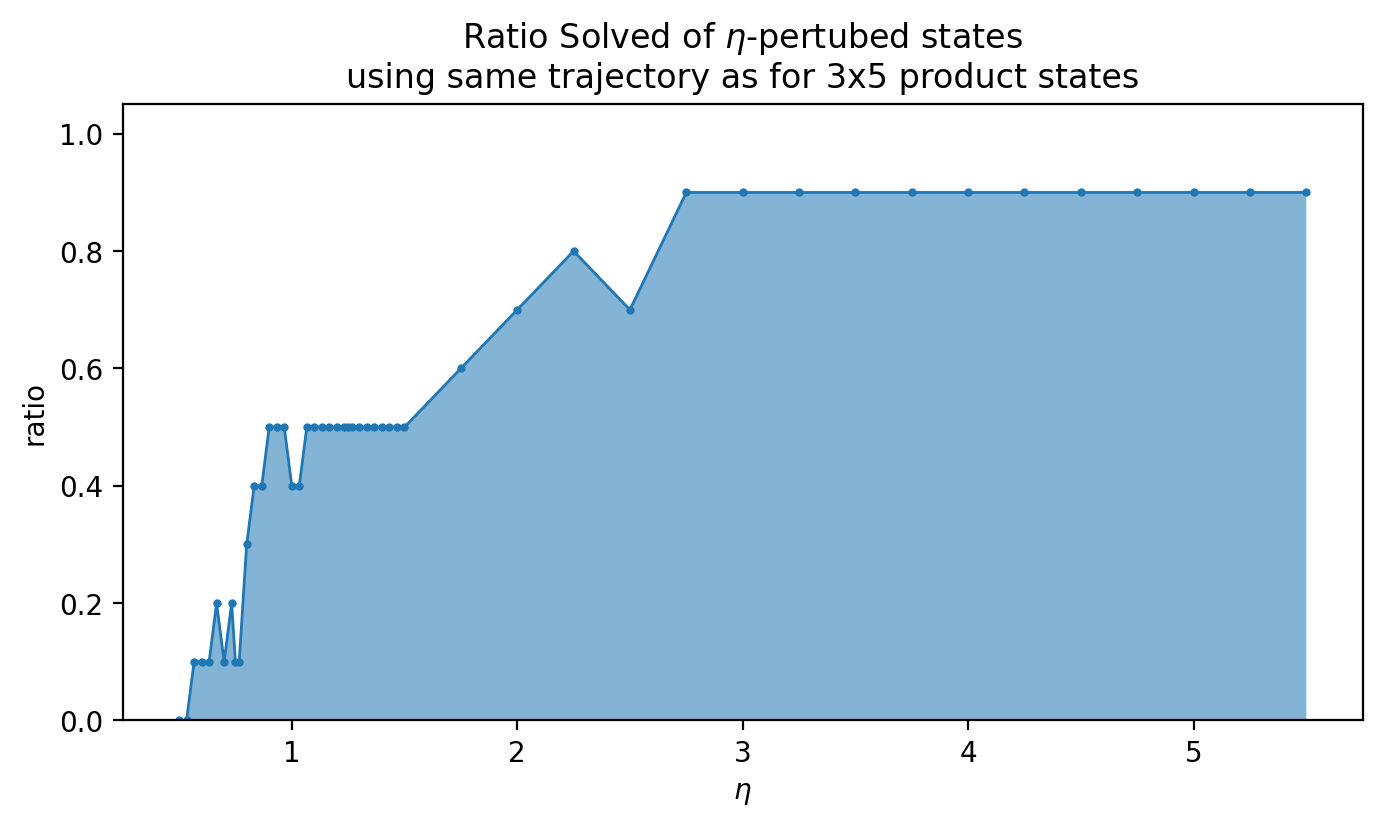

In [101]:

bins_x = []
bins_h = []
for k in eta_pertubation_results3:
    vals = np.array(eta_pertubation_results3[k])
    bins_x.append(k)
    bins_h.append(np.count_nonzero(vals != np.inf) / len(vals))

sk = np.argsort(bins_x)
bins_x = np.array(bins_x)[sk]
bins_y = np.array(bins_h)[sk]
fig, ax = plt.subplots(figsize=(8,4))
ax.fill_between(bins_x, 0, bins_y, alpha=0.55)
ax.plot(bins_x, bins_y, marker='.', lw=1, markersize=4)
ax.set_title("Ratio Solved of $\eta$-pertubed states\nusing same trajectory as for 3x5 product states")
ax.set_xlabel("$\eta$")
ax.set_ylabel("ratio")
ax.set_ylim(0, 1.05)

In [102]:
fig.savefig("eta-vs-ratio-solved.pdf", dpi=160)

In [103]:
list(map(len, test_actions))

[71, 76, 79, 73, 75, 72, 73, 68, 72, 62]